In [1]:
import pandas as pd 
import numpy as np 


In [2]:
np.random.seed(23)

In [4]:
mu_vec1= np.array([0,0,0])
cov_mat1= np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1,cov_mat1,20)

In [5]:
df =pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target']=1

In [11]:
mu_vec2= np.array([1,1,1])
cov_mat2= np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2,cov_mat2,20)

df1 =pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])
df1['target']=0

df = pd.concat([df, df1], ignore_index=True)


In [12]:
df.head(5)

,feature1,feature2,feature3,target
0,0.666988,0.025813,-0.777619,1
1,0.948634,0.701672,-1.051082,1
2,-0.367548,-1.137460,-1.322148,1
3,1.772258,-0.347459,0.670140,1
4,0.322272,0.060343,-1.043450,1


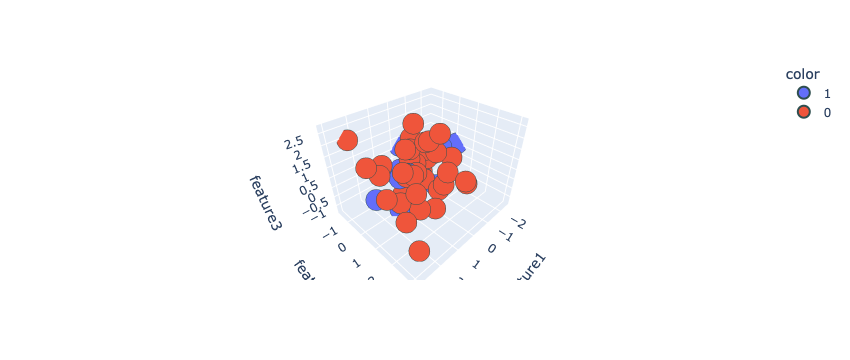

In [18]:
import plotly.express as px

fig = px.scatter_3d( df, x=df['feature1'],y=df['feature2'],z=df['feature3'],
                   color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12, line=dict(width=2,
                                                color='DarkSlateGrey')),
                 selector=dict(mode='markers'))
fig.show()

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:, 0:3] = scaler.fit_transform(df.iloc[:, 0:3])

In [23]:
cov_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('covariance matrix:\n',cov_matrix)

covariance matrix:
 [[1.01694915 0.25294383 0.0169896 ]
 [0.25294383 1.01694915 0.1271753 ]
 [0.0169896  0.1271753  1.01694915]]


In [24]:
eigen_values,eigen_vectors= np.linalg.eig(cov_matrix)

In [26]:
eigen_values

array([1.30713783, 0.74037979, 1.00332983])

In [27]:
eigen_vectors

array([[-0.62859462, -0.63618671, -0.44736481],
       [-0.69813019,  0.71506845, -0.03593525],
       [-0.34275799, -0.28973018,  0.89362933]])

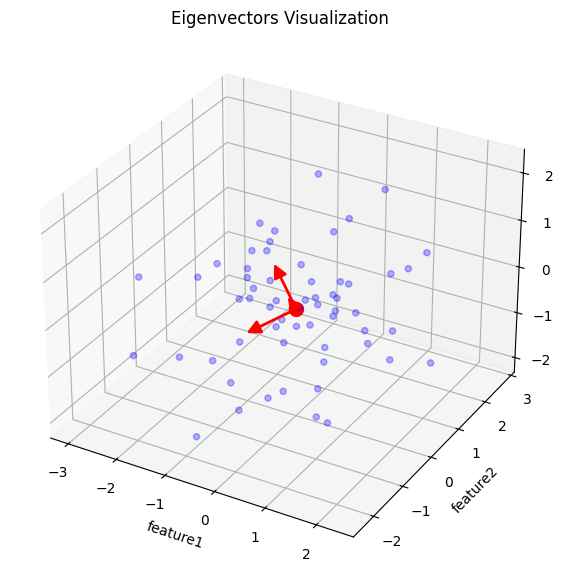

In [30]:
%matplotlib inline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

# -----------------------------
# Custom 3D Arrow class (FIXED)
# -----------------------------
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        return min(zs3d)

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, ax.get_proj())
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)


# -----------------------------
# Example Data (replace with yours)
# -----------------------------
# df must already exist with feature1, feature2, feature3
# eigen_vectors must be computed from PCA or covariance matrix

# Example fallback (remove if you already have data)
# df = pd.DataFrame(np.random.randn(100, 3), columns=['feature1','feature2','feature3'])
# eigen_vectors = np.linalg.svd(np.cov(df.T))[0]

# -----------------------------
# Plot
# -----------------------------
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(df['feature1'], df['feature2'], df['feature3'],
           color='blue', alpha=0.3)

# Mean point
mean_vec = [df['feature1'].mean(),
            df['feature2'].mean(),
            df['feature3'].mean()]

ax.scatter(mean_vec[0], mean_vec[1], mean_vec[2],
           color='red', s=100)

# Eigenvectors
for v in eigen_vectors.T:
    arrow = Arrow3D(
        [mean_vec[0], mean_vec[0] + v[0]],
        [mean_vec[1], mean_vec[1] + v[1]],
        [mean_vec[2], mean_vec[2] + v[2]],
        mutation_scale=20,
        lw=2,
        arrowstyle="-|>",
        color="r"
    )
    ax.add_artist(arrow)

# Labels
ax.set_xlabel('feature1')
ax.set_ylabel('feature2')
ax.set_zlabel('feature3')
plt.title('Eigenvectors Visualization')

plt.show()

In [31]:
pc = eigen_vectors[0:2]
pc

array([[-0.62859462, -0.63618671, -0.44736481],
       [-0.69813019,  0.71506845, -0.03593525]])

In [32]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,0.948593,-0.370948,1
1,0.448168,-0.033909,1
2,2.616046,-0.544817,1
3,-0.141463,-1.449987,1
4,1.257284,-0.103828,1


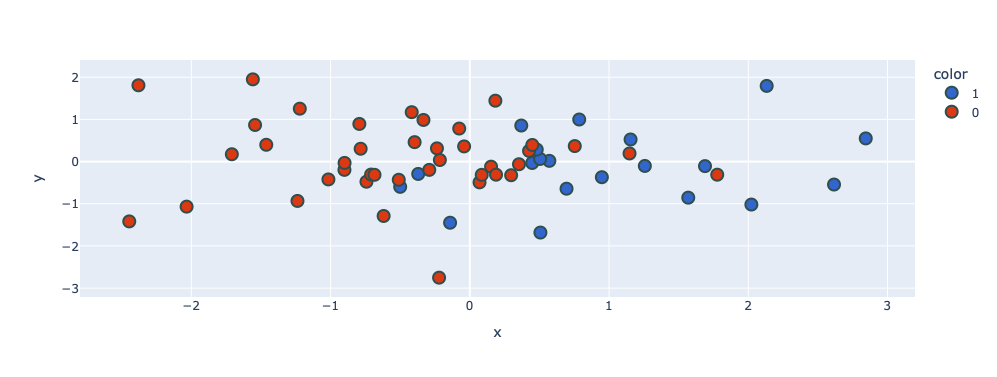

In [33]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()